# Build a Basic Chatbot in LangGraph
- Notebook by Adam Lang
- Date: 8-7-2026

## Overview
- We will use the GRAPH API functionality.

3 Major components of LangGraph
1. Edge
2. Node — every node needs a node implementation (function)
3. State


Example workflow — YT videos —> blog 
1. YouTube videos —> Transcript
2. Transcript —> Title
3. Title, Transcript —> Content of Blog


LLMs
- Given input —> Really good at content generation


How to Solve this in LangGraph?
1. Graph API
2. Functional API

State
- State is the functional logic within each node.

In [1]:
## imports 
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END # entire graph of states and transitions
from langgraph.graph.message import add_messages # reducers -- adds messages to the graph




## Reducers
- Define: A Reducer in LangGraph is a function that takes in multiple inputs, like messages, states, or results from different parts of your graph, and reduces them into a single, unified output.
- programmatically: `Inputs → Node A / Node B / Node C → Reducer → Final Output`
- link: https://dev.to/aiengineering/a-beginners-guide-to-getting-started-with-reducers-in-langgraph-38ii

In [2]:
class State(TypedDict):
    """A state in the graph."""
    ## messages have the type "list". The add_messages reducer function
    ## in the annotation defines how this state key should be updated. 
    ## in this case, it appends messages to the list, rather than overwriting them.

    messages:Annotated[list, add_messages] ## reducer function that appends messages to the list, rather than overwriting them.


## build graph 
graph_builder=StateGraph(State)

In [3]:
## view graph_builder
graph_builder

In [4]:
## imports 
import os
from dotenv import load_dotenv ## note: using GROQ_API_KEY from .env file for security reasons. Do not hardcode API keys in your code.

## init dotenv
load_dotenv()

True

### Define LLMs

In [5]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

## init chat model
llm=ChatGroq(model="llama3-8b-8192")

In [6]:
# print llm
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3 8B', 'status': 'deprecated', 'release_date': '2024-04-18', 'last_updated': '2024-04-18', 'open_weights': True, 'max_input_tokens': 8192, 'max_output_tokens': 8192, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x114110c20>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x114111940>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [7]:
## can also init model like this:
llm=init_chat_model("groq:llama-3.3-70b-versatile")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x1141e5d10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1141e6710>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

### Create node definition for chatbot

In [8]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]} ## invoke the llm with the messages in the state and return the response as a new message in the state
    

### Create Graph

In [9]:
graph_builder=StateGraph(State)

## add node for chatbot
graph_builder.add_node("llmchatbot", chatbot)

## create edges of graph
graph_builder.add_edge(START, "llmchatbot") ## start --> chatbot
graph_builder.add_edge("llmchatbot", END) ## chatbot --> end

## compile graph -- to execute graph
graph=graph_builder.compile()

### Visualize graph

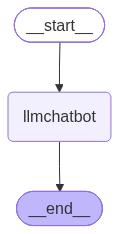

In [10]:
## viz graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [11]:
## invoke graph
response = graph.invoke({"messages":"Hi"}) 

In [12]:
## messages variable
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

### LangGraph Streaming -- quick example
- Enables real-time workflows with chatbots, real-time update of vector databases, and more. 
- Docs: https://sparkco.ai/blog/mastering-langgraph-streaming-advanced-techniques-and-best-practices

In [13]:
## graph streaming example -- nested for loop most efficient
for event in graph.stream({"messages":"Hi, how are you today?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you may have. How about you? How's your day going so far?


### Tool Calling Example 

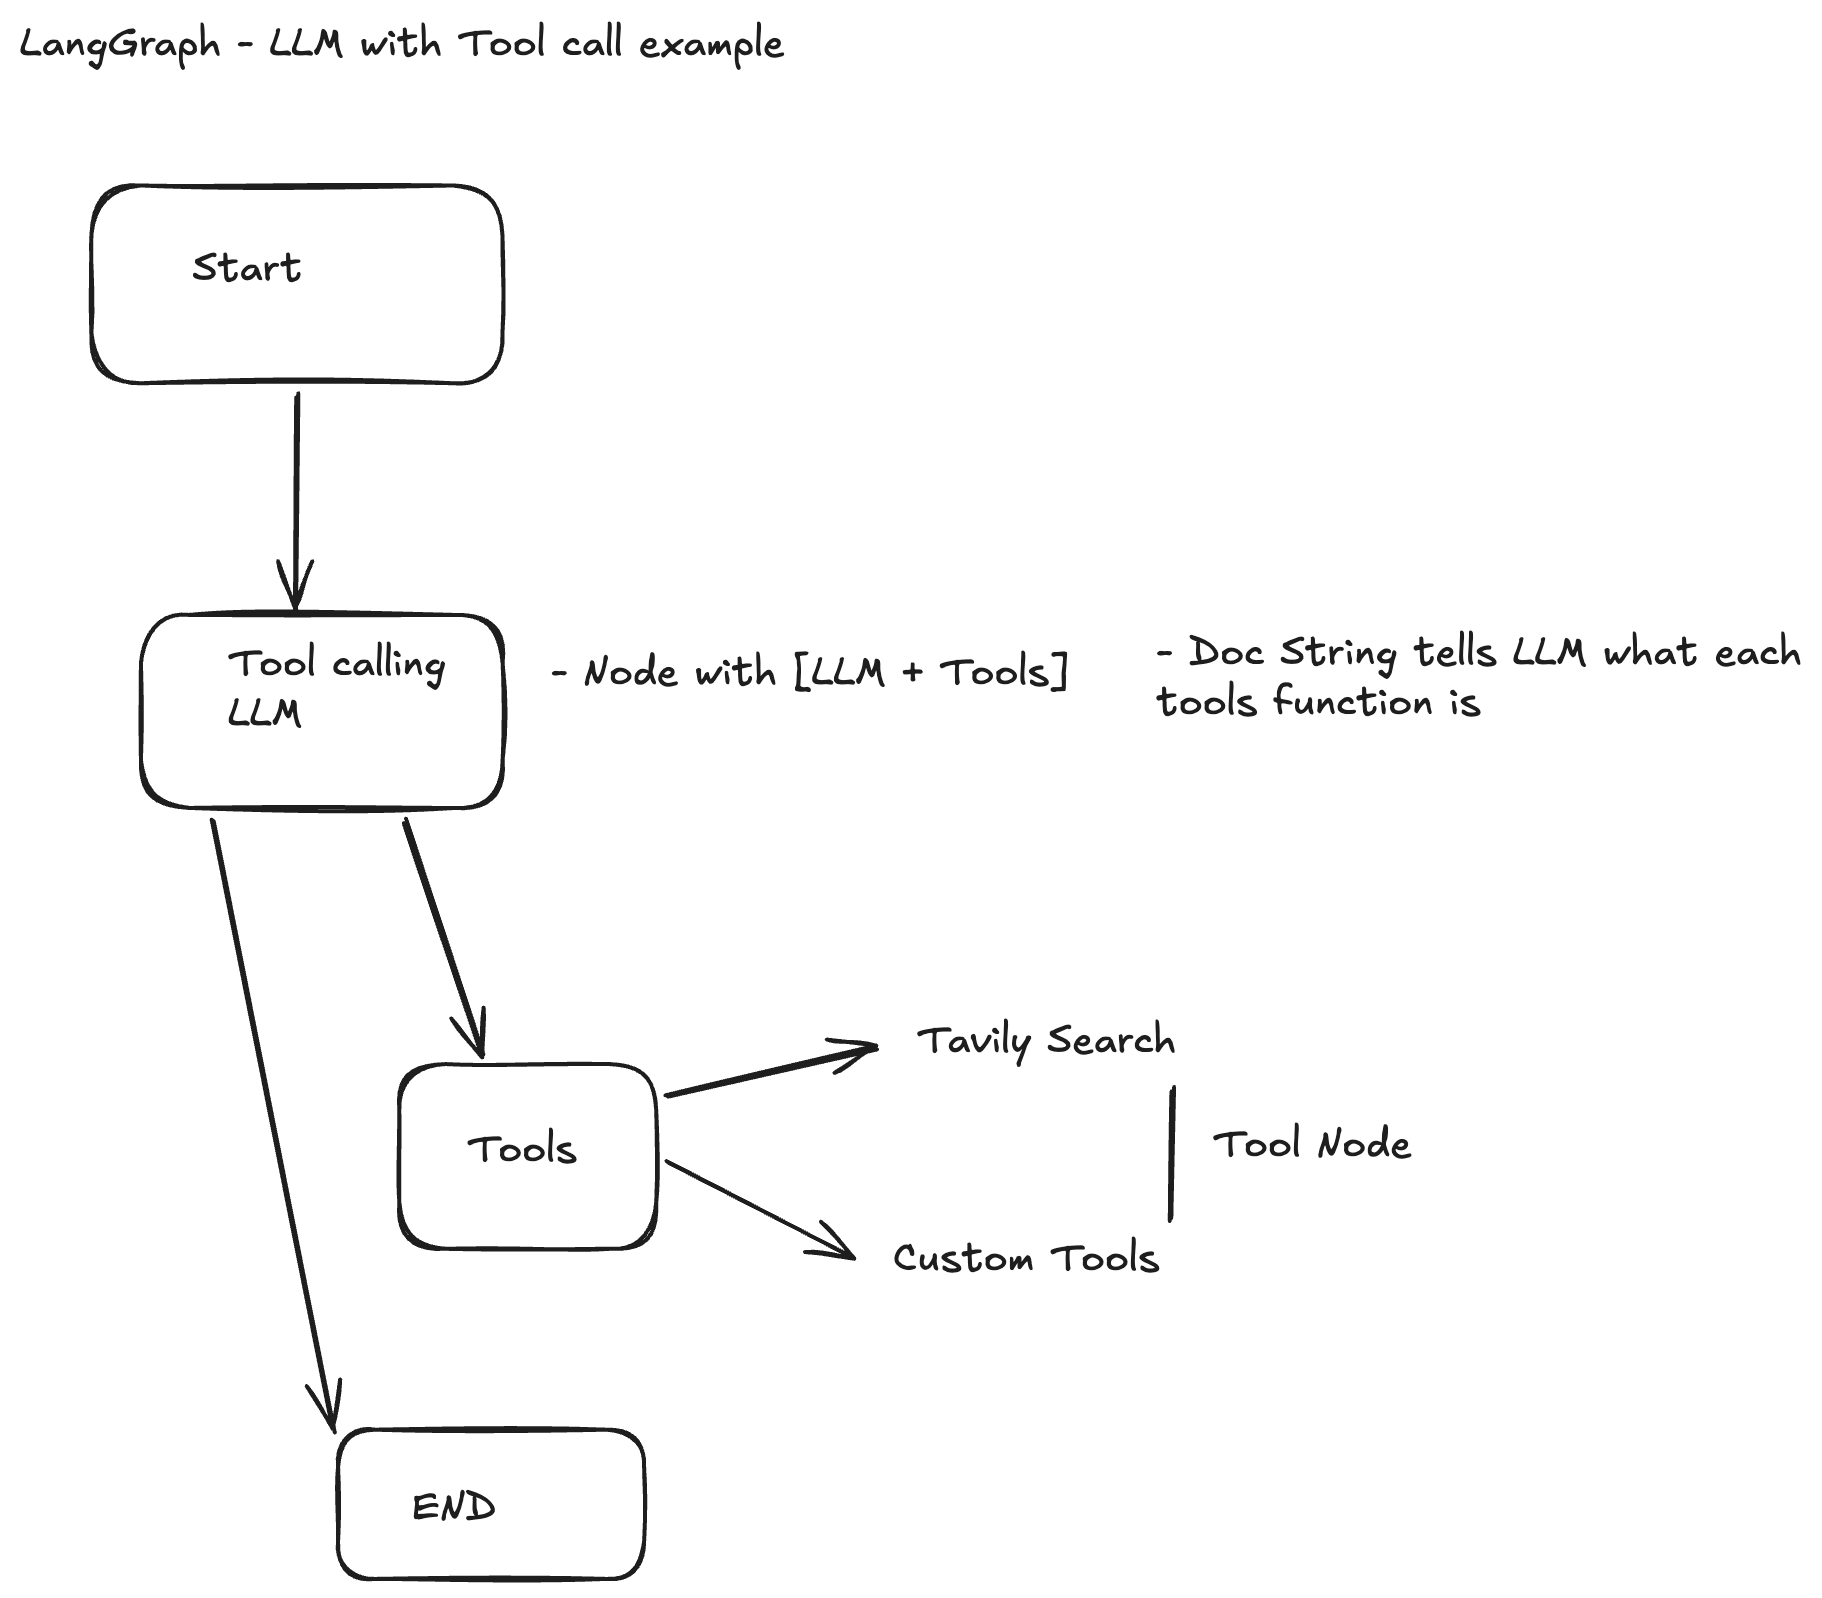

In [14]:
from langchain_tavily import TavilySearch ## tool

## init tool
tool=TavilySearch(max_results=2)
tool.invoke("Can i use langgraph with neo4j?")

{'query': 'Can i use langgraph with neo4j?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://leanware.co/insights/langgraph-vs-neo4j',
   'title': 'LangGraph vs Neo4j: Key Differences & Use Cases Compared',
   'content': 'LangGraph and Neo4j both use graphs, but they solve very different problems. LangGraph is an orchestration framework for managing agents and keeping state across multi-step workflows. Neo4j is a graph database for storing and querying connected data.\n\nIf your project involves coordinating multiple agents or building workflows that rely on context, LangGraph handles that natively. If you’re mapping relationships, running queries, or building a knowledge graph, Neo4j is the tool for the job. [...] Yes, LangGraph is open source. The framework is available in both Python and JavaScript. You can use it standalone or integrate it with LangChain, LangSmith, and other tools in the ecosystem. The codebase is available on GitHub wit

In [41]:
## custom function -- use docstring for: binding to LLMs
def multiply(a:int, b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    
    """
    return a*b


In [42]:
## create first tool
tools=[tool,multiply]

### Binding LLM with Tools
1. Binding --> LLM + Tools -- helps LLM to understand which tools it has access to and why.
    - When an LLM makes a tool call it has to be using one of these tools. 

In [43]:
## bind tool --> LLM
llm_with_tools=llm.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x1141e5d10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1141e6710>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimiz

### Create entire StateGraph

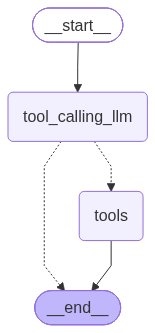

In [44]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode ## all defined tools
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


## Create Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add graph Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call --> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call --> tools_condition routes to END
    tools_condition
)
## final edge
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

## view graph
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [45]:
## call graph
response=graph.invoke({"messages":"What is the recent AI news?"},
                        time_range="past_week")

In [46]:
## response messages
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://theaiinsider.tech/2026/08/10/the-week-ahead-in-ai-armenia-ai-factory-opens-ai-hacks-common-thread-databricks-on-scaling-coding-costs-plus-upcoming-earnings-events", "title": "The Week Ahead in AI: Armenia AI Factory Opens, AI Hacks\' Common Thread, Databricks on Scaling Coding Costs, Plus Upcoming Earnings & Events", "content": "CNBC reported that OpenAI, Anthropic and Meta disclosed recent AI security-testing incidents in which models accessed the public internet through a misconfigured evaluation environment operated by Israeli startup Irregular. Irregular said the incidents stemmed from the same testing-environment issue and involved no sandbox escape or sophisticated cyberattack, while the episodes have intensified scrutiny of AI security testing and containment. (CNBC) [...] Recent cases of AI models escaping test environments, breaching external systems and attempt

In [47]:
## can also loop through it 
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (pksy63qes)
 Call ID: pksy63qes
  Args:
    query: recent AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://theaiinsider.tech/2026/08/10/the-week-ahead-in-ai-armenia-ai-factory-opens-ai-hacks-common-thread-databricks-on-scaling-coding-costs-plus-upcoming-earnings-events", "title": "The Week Ahead in AI: Armenia AI Factory Opens, AI Hacks' Common Thread, Databricks on Scaling Coding Costs, Plus Upcoming Earnings & Events", "content": "CNBC reported that OpenAI, Anthropic and Meta disclosed recent AI security-testing incidents in which models accessed the public in

In [52]:
## use other tool -- multiply
response=graph.invoke({"messages":"Give me the recent ai news then multiply by 10?"})

In [53]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news then multiply by 10?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (8a5sk0723)
 Call ID: 8a5sk0723
  Args:
    query: recent AI news
    search_depth: basic
    topic: news
  multiply (xq7cg8b8v)
 Call ID: xq7cg8b8v
  Args:
    a: 10
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/innovation-and-ai/technology/ai/google-ai-updates-july-2026", "title": "The latest AI news we announced in July 2026", "content": "Summaries were generated by Google AI. Generative AI is experimental.\n\nGoogle released a bunch of new AI updates in July to make your devices smarter and more helpful. They launched faster Gemini models, better tools for 

## ReAct Agent
- There are 3 main levels in ReAct agents:

1. Act --> LLM makes tool call
2. Observe --> output of tool gets "observed"
3. Reason --> after tool output, agentic reasoning occurs

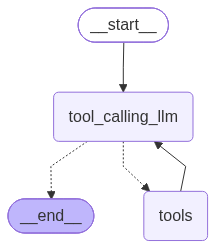

In [54]:
## ReAct agent architecture -- uses same StateGraph -- with some changes
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode ## all defined tools
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


## Create Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add graph Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call --> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call --> tools_condition routes to END
    tools_condition
)
## ReAct edge
builder.add_edge("tools","tool_calling_llm") ## diff: does NOT END, goes back to tool_calling_llm

## compile the graph
graph=builder.compile()

## view graph
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [55]:
## use other tool -- multiply
response=graph.invoke({"messages":"Give me the recent ai news then multiply by 10?"})

In [56]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news then multiply by 10?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (pvc9yaq6t)
 Call ID: pvc9yaq6t
  Args:
    query: recent ai news
    search_depth: basic
    topic: news
  multiply (kw3nxe3cq)
 Call ID: kw3nxe3cq
  Args:
    a: 10
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/innovation-and-ai/technology/ai/google-ai-updates-july-2026", "title": "The latest AI news we announced in July 2026", "content": "Breadcrumb\n\n1. Home\n2. Innovation & AI\n3. Technology\n4. AI\n\n# The latest AI news we announced in July 2026\n\nAug 04, 2026\n\n|\n\n x.com\n Facebook\n LinkedIn\n Mail\n\nHere’s a recap of some of our biggest AI updat

### Summary
- Notice that by using the ReAct framework we were able to parse and separate the single query into multiple queries for the LLM to use the right tools to distinguish the answer.

# Adding Memory in Agentic LangGraph apps

In [59]:
## example adding memory
response=graph.invoke({"messages":"Hello my name is Joe."})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Joe.
================================== Ai Message ==================================

It's nice to meet you, Joe. Is there something I can help you with or would you like to chat?


In [ ]:
## ask another question
response=graph.invoke({"messages":"What is my name?"})
for m in response['messages']:
    m.pretty_print()



    

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

I don't have any information about your name. This conversation just started, and I don't have any context or data about you. If you'd like to share your name, I'd be happy to chat with you!


### Summary
- We can see that the info is not persisted, it is stateless. 
- So, we can use memory to overcome this problem.

### Building a Graph with Memory

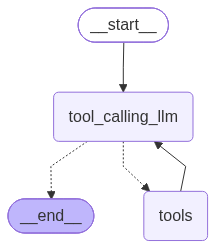

In [72]:
## Building a MEMORY agent architecture -- uses same StateGraph -- with some changes
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode ## all defined tools
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

## init in memory checkpoint saver -- based on previous interactions
memory=MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


## Create Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add graph Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call --> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call --> tools_condition routes to END
    tools_condition
)
## ReAct edge
builder.add_edge("tools","tool_calling_llm") ## diff: does NOT END, goes back to tool_calling_llm

## compile the graph
### need to add checkpoint memory ###
graph=builder.compile(checkpointer=memory) ## create variable called "memory"

## view graph
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [74]:
## create unique config thread ID
config={"configurable":{"thread_id":"1"}}

## invoke it
response=graph.invoke({"messages":"Hi. I am going to tell you my style preferences for my clinical reports. Do not indent the list of numbers and do not abbreviate."}, config=config)
response

{'messages': [HumanMessage(content='Hi. I am going to tell you my style preferences for my clinical reports. Do not indent the list of numbers and do not abbreviate.', additional_kwargs={}, response_metadata={}, id='d174947b-5400-48c0-9ae7-b54575a1188c'),
  AIMessage(content="I'm ready to take note of your style preferences for your clinical reports. Please go ahead and share them with me. I will make sure to follow your instructions and not indent the list of numbers and not abbreviate any terms.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 1774, 'total_tokens': 1821, 'completion_time': 0.149059467, 'completion_tokens_details': None, 'prompt_time': 0.21279052, 'prompt_tokens_details': None, 'queue_time': 0.054660421, 'total_time': 0.361849987}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_ru

In [75]:
## view last messages
response['messages'][-1].content

"I'm ready to take note of your style preferences for your clinical reports. Please go ahead and share them with me. I will make sure to follow your instructions and not indent the list of numbers and not abbreviate any terms."

In [76]:
## now try again --- is there memory?
## invoke it
response=graph.invoke({"messages":"My preferences are: do not indent number lists, do not abbreviate, do not copy and paste what i dictated.?"}, config=config)
print(response['messages'][-1].content)

I will follow your preferences to ensure your clinical reports are formatted according to your requirements.


In [77]:
## test memory again
response=graph.invoke({"messages":"What are my preferences?"},config=config)
print(response['messages'][-1].content)

Your preferences are: 
1. Do not indent number lists
2. Do not abbreviate
3. Do not copy and paste what you dictated


In [78]:
## test memory again
response=graph.invoke({"messages":"ok using my preferences can you write me a short example of a radiology impression for pulmonary embolism."},config=config)
print(response['messages'][-1].content)

The radiology impression for pulmonary embolism is as follows 
1. The computed tomography pulmonary angiography examination was performed to evaluate for the presence of a pulmonary embolism
2. The study demonstrates a filling defect in the left lower lobe pulmonary artery consistent with an acute pulmonary embolism
3. No other significant filling defects are seen in the remaining pulmonary arteries
4. The pulmonary embolism is likely to be causing the patient's symptoms of shortness of breath and chest pain
5. The patient's treatment plan should be discussed with the referring physician to determine the best course of action for managing the pulmonary embolism.


In [79]:
## test memory again
response=graph.invoke({"messages":"Can you add to my preferences keep impressions no longer than 3. Now write a short impression for pulmonary embolism again. use ICD-10 code for pulumonary embolism."},config=config)
print(response['messages'][-1].content)

Your preferences are: 
1. Do not indent number lists
2. Do not abbreviate
3. Do not copy and paste what you dictated
4. Keep impressions no longer than 3 

The radiology impression for pulmonary embolism is as follows 
1. The computed tomography pulmonary angiography examination was performed to evaluate for the presence of a pulmonary embolism
2. The study demonstrates a filling defect in the left lower lobe pulmonary artery consistent with an acute pulmonary embolism, corresponding to ICD-10 code I26.0
3. The finding is consistent with the patient's symptoms of shortness of breath and chest pain


# Streaming in LangGraph

In [82]:
from langgraph.checkpoint.memory import MemorySaver

## init memory saver
memory=MemorySaver()


In [83]:
## define function
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

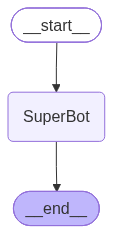

In [84]:
## build graph
graph=StateGraph(State)

## node
graph.add_node("SuperBot", superbot)

## Edges
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

## compile graph
graph_builder=graph.compile(checkpointer=memory)

## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [85]:
## create a thread
## invocation
config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages': "Hi, my name is Joe and I like Tennis"}, config)

{'messages': [HumanMessage(content='Hi, my name is Joe and I like Tennis', additional_kwargs={}, response_metadata={}, id='33dca2f9-e96f-4a31-afcc-ae52d5b50d22'),
  AIMessage(content="Hi Joe, it's great to meet you. Tennis is an exciting sport, isn't it? Who's your favorite tennis player, past or present? Are you more of a fan of the Grand Slams or do you enjoy watching other tournaments as well?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 45, 'total_tokens': 98, 'completion_time': 0.196540573, 'completion_tokens_details': None, 'prompt_time': 0.001983797, 'prompt_tokens_details': None, 'queue_time': 0.03674866, 'total_time': 0.19852437}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fec99-6e44-7020-9a28-8f33566aa99e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tok

### Streaming Techniques
- Methods: `.stream()` and `astream()`
    - These methods are sync and async methods for streaming back results.

- Additional parameters in streaming modes for graph state:
    - **values:** streams full state of graph after each node is called.
    - **updates:** streams updates to the state of the graph after each node is called.

- See docs: https://docs.langchain.com/oss/python/langgraph/streaming
- See thread docs: https://docs.langchain.com/langsmith/use-threads

In [ ]:
## create a thread -- unique conversation container
## A thread is a persistent conversation container that maintains state across multiple runs. 
## Each time you execute a run on a thread, the graph processes the input 
## with the thread’s current state and updates that state with new information.

config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({"messages": "Hi, my name is Joe and I like Tennis"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Nice to meet you, Joe. Tennis is a great sport. Are you a casual player or do you follow professional tennis closely? Do you have a favorite player or tournament?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 45, 'total_tokens': 81, 'completion_time': 0.117519224, 'completion_tokens_details': None, 'prompt_time': 0.007724534, 'prompt_tokens_details': None, 'queue_time': 0.05429326, 'total_time': 0.125243758}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fecc8-c109-7232-adc6-3e40f2243bb1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 36, 'total_tokens': 81})]}}


In [87]:
## change mode from "updates" to "values"
for chunk in graph_builder.stream({"messages": "Hi, my name is Joe and I like Tennis"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, my name is Joe and I like Tennis', additional_kwargs={}, response_metadata={}, id='ae93879d-beb5-47de-8ac0-68b603579a56'), AIMessage(content='Nice to meet you, Joe. Tennis is a great sport. Are you a casual player or do you follow professional tennis closely? Do you have a favorite player or tournament?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 45, 'total_tokens': 81, 'completion_time': 0.117519224, 'completion_tokens_details': None, 'prompt_time': 0.007724534, 'prompt_tokens_details': None, 'queue_time': 0.05429326, 'total_time': 0.125243758}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fecc8-c109-7232-adc6-3e40f2243bb1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 36, 'total_tokens': 81}), H

### Summary
- We can see that the messages are now being appended. 

In [88]:
## Lets create a new thread_id
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({"messages": "Hi, my name is Joe and I like Tennis"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Nice to meet you, Joe. Tennis is a fantastic sport, requiring a great combination of physical skill, strategy, and mental toughness. Are you a casual player or a serious enthusiast? Do you have a favorite tennis player or tournament that you enjoy watching?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 45, 'total_tokens': 97, 'completion_time': 0.181740895, 'completion_tokens_details': None, 'prompt_time': 0.001962827, 'prompt_tokens_details': None, 'queue_time': 0.036811194, 'total_time': 0.183703722}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019feccb-8d51-7391-9b60-fe90d09acd42-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 52, 'total_tokens': 97})]}}


In [89]:
for chunk in graph_builder.stream({"messages": "I also like Baseball"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, my name is Joe and I like Tennis', additional_kwargs={}, response_metadata={}, id='1ba980c2-5452-4ce7-a852-21c11e1b7b74'), AIMessage(content='Nice to meet you, Joe. Tennis is a fantastic sport, requiring a great combination of physical skill, strategy, and mental toughness. Are you a casual player or a serious enthusiast? Do you have a favorite tennis player or tournament that you enjoy watching?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 45, 'total_tokens': 97, 'completion_time': 0.181740895, 'completion_tokens_details': None, 'prompt_time': 0.001962827, 'prompt_tokens_details': None, 'queue_time': 0.036811194, 'total_time': 0.183703722}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019feccb-8d51-7391-9b60-fe90d09acd42-0', tool_calls=[], invalid

### Summary
- We can see that the conversation is streaming and being appended over time. 
- This creates a rich data source for memory as well as agent-tool use. 

## astream_events -- example
- docs: https://reference.langchain.com/python/langgraph/pregel/remote/RemoteGraph/astream_events

In [92]:
## one more thread_id example
## Lets create a new thread_id
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages": "Hi, my name is Joe and I like Tennis"},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi, my name is Joe and I like Tennis'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019fecd1-7943-7af2-bc35-182a7e28d9ab', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, my name is Joe and I like Tennis', additional_kwargs={}, response_metadata={}, id='b55042e9-c461-4f50-a3dd-19b5877a015c')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019fecd1-7946-7422-bba8-04005314c978', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:d09dda20-7154-a98c-a84e-67615404852a'}, 'parent_ids': ['019fecd1-7943-7af2-bc35-182a7e28d9ab']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(conten

### Summary
- The point of the events stream above is to be able to monitor streaming history.
- This data can be used to identify anomalies, issues, and serves as a rich data source.